In [101]:
import torch
import torch.nn as nn
import numpy as np

# Import pprint, module we use for making our print statements prettier
import pprint
pp = pprint.PrettyPrinter()

In [3]:
x = torch.empty(2, 3)
print(x)

tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [7]:
x = torch.rand(2, 2, dtype=torch.float16)
print(x)

tensor([[0.7129, 0.5161],
        [0.1777, 0.3945]], dtype=torch.float16)


In [8]:
x.dtype

torch.float16

In [9]:
x.size()

torch.Size([2, 2])

In [ ]:
torch.ones(2,2)

tensor([[1., 1.],
        [1., 1.]])

In [11]:
x = torch.rand(2,2)
y = torch.rand(2,2)

z = x / y
print(z)

z = torch.div(x,y)
z

tensor([[0.3280, 4.0785],
        [1.2013, 0.0799]])


tensor([[0.3280, 4.0785],
        [1.2013, 0.0799]])

In [19]:
a = torch.ones(5)
b = a.numpy()
b

array([1., 1., 1., 1., 1.], dtype=float32)

In [20]:
a.add_(1)
a

tensor([2., 2., 2., 2., 2.])

It makes changes directly onto the original tensor

In [22]:
b

array([2., 2., 2., 2., 2.], dtype=float32)

In [24]:
x = torch.rand(5, 3)
x

tensor([[0.8915, 0.2739, 0.3665],
        [0.9604, 0.9082, 0.0499],
        [0.2043, 0.9408, 0.3263],
        [0.3813, 0.5958, 0.5656],
        [0.5106, 0.4310, 0.2295]])

In [25]:
x[1,:]

tensor([0.9604, 0.9082, 0.0499])

In [26]:
x[:,1]

tensor([0.2739, 0.9082, 0.9408, 0.5958, 0.4310])

In [31]:
x = torch.randint(low=0, high=10, size=(5,3,3))
x

tensor([[[2, 7, 9],
         [6, 8, 3],
         [1, 4, 0]],

        [[7, 9, 8],
         [4, 0, 7],
         [8, 4, 3]],

        [[3, 6, 3],
         [8, 1, 7],
         [2, 2, 6]],

        [[1, 8, 3],
         [0, 2, 9],
         [1, 8, 7]],

        [[0, 4, 7],
         [8, 0, 3],
         [7, 9, 4]]])

In [ ]:
x[1,0,-1] + x[0,0,0] 

tensor(10)

In [40]:
x[1,1,1].item()

0

In [42]:
x[0,:,:]

tensor([[2, 7, 9],
        [6, 8, 3],
        [1, 4, 0]])

In [41]:
x[0,:,:].view(9)

tensor([2, 7, 9, 6, 8, 3, 1, 4, 0])

In [50]:
x[0,:,:].view(-1,3)

tensor([[2, 7, 9],
        [6, 8, 3],
        [1, 4, 0]])

In [52]:
a = np.ones(5)
b = torch.from_numpy(a)

In [54]:
y = x[0,:,:]
y.numpy()

array([[2, 7, 9],
       [6, 8, 3],
       [1, 4, 0]])

In [ ]:
x = torch.Tensor([[1, 2.2, 9.6], [4, -7.2, 6.3]])
x


tensor([[ 1.0000,  2.2000,  9.6000],
        [ 4.0000, -7.2000,  6.3000]])

In [8]:
x.mean(axis=0)

tensor([ 2.5000, -2.5000,  7.9500])

In [10]:
x[0,:]

tensor([1.0000, 2.2000, 9.6000])

In [11]:
x[:,0]

tensor([1., 4.])

# Autogradient 

In [25]:
x = torch.tensor([2.], requires_grad=True)
z = torch.tensor([2.], requires_grad=True)
y = x * x * 3 + x
y.backward()
pp.pprint(x.grad)
pp.pprint(z.grad)

tensor([13.])
None


In [26]:
x = torch.tensor([2.], requires_grad=True)
z = torch.tensor([2.], requires_grad=True)
y = x * x * 3 + z
y.backward()
pp.pprint(x.grad)
pp.pprint(z.grad)

tensor([12.])
tensor([1.])


In [98]:
x = torch.rand(5, requires_grad=True)*10
x

tensor([6.9104, 7.1712, 0.5467, 0.0259, 2.1934], grad_fn=<MulBackward0>)

In [99]:
y = x + 2
y

tensor([8.9104, 9.1712, 2.5467, 2.0259, 4.1934], grad_fn=<AddBackward0>)

In [100]:
z = y*y*2
#z = z.mean()
z

tensor([158.7895, 168.2227,  12.9719,   8.2084,  35.1688],
       grad_fn=<MulBackward0>)

In [101]:
# We have to provide a direction, such that it's easy to compute the gradient.
# Becasue the Jacobian Matrix very expensive (m*n)
v = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0], dtype=torch.float32)
z.backward(v) #dz/dx

In [102]:
x.grad

/var/folders/6h/7_s8d7dn5p565dythb22sn0c0000gn/T/ipykernel_69714/3730140797.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1741997211379/work/build/aten/src/ATen/core/TensorBody.h:494.)
  x.grad


In [137]:
x = torch.tensor([2., 3.], requires_grad=True)
y = torch.tensor([1., 2.], requires_grad=True)   

z = x*y   # z is NOT a leaf
print(z)
v = torch.tensor([1.0, 0.0], dtype=torch.float32)
z.backward(v)
x.grad

tensor([2., 6.], grad_fn=<MulBackward0>)


tensor([1., 0.])

In [138]:
x = torch.tensor([2., 3.], requires_grad=True)
y = torch.tensor([1., 2.], requires_grad=True)   

z = x*y   # z is NOT a leaf
print(z)
v2 = torch.tensor([0.0, 1.0], dtype=torch.float32)
z.backward(v2)
x.grad

tensor([2., 6.], grad_fn=<MulBackward0>)


tensor([0., 2.])

In [142]:
weights = torch.ones(4, requires_grad = True)

for epoch in range(5):
    model_output = (weights*3).sum()

    model_output.backward()

    print(weights.grad)
    
    weights.grad.zero_()

tensor([3., 3., 3., 3.])
tensor([3., 3., 3., 3.])
tensor([3., 3., 3., 3.])
tensor([3., 3., 3., 3.])
tensor([3., 3., 3., 3.])


# Backpropagation

In [146]:
x = torch.tensor(1.0)
y = torch.tensor(2.0)

w = torch.tensor(1.0, requires_grad = True)

# Forward Pass
y_hat = w * x
loss = (y - y_hat)**2

print(loss)

tensor(1., grad_fn=<PowBackward0>)


In [147]:
# Backward Pass

loss.backward()
print(w.grad)

tensor(-2.)


# Linear Layers

In [ ]:
input = torch.ones(2,3,4)


tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

In [60]:
input = torch.ones(2,3,4)

linear = torch.nn.Linear(4,2)
linear_output = linear(input)
sigmoid = torch.nn.Sigmoid()
output = sigmoid(linear_output)

list(linear.parameters())


[Parameter containing:
 tensor([[ 0.4885, -0.3374,  0.3603,  0.0455],
         [-0.0069, -0.3272,  0.3770,  0.1224]], requires_grad=True),
 Parameter containing:
 tensor([-0.0791, -0.4207], requires_grad=True)]

In [61]:
linear_output.shape

torch.Size([2, 3, 2])

In [62]:
output.shape

torch.Size([2, 3, 2])

In [64]:
block = torch.nn.Sequential(
    torch.nn.Linear(4,2),
    torch.nn.Sigmoid()
)

input = torch.ones(2,3,4)
output = block(input)
output

tensor([[[0.7344, 0.3255],
         [0.7344, 0.3255],
         [0.7344, 0.3255]],

        [[0.7344, 0.3255],
         [0.7344, 0.3255],
         [0.7344, 0.3255]]], grad_fn=<SigmoidBackward0>)

In [65]:
class MultilayerPerceptron(torch.nn.Module):
    def __init__(self, input_size, hidden_size):
        # Call to the __init__ function of the super class
        super(MultilayerPerceptron, self).__init__()

        # Bookkeeping: Saving the initialization parameters
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Defining the model
        # There's not anything specific about naming "self.model"
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.input_size, self.hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(self.hidden_size, self.input_size),
            torch.nn.Sigmoid()
        )
    
    def forward(self, X):
        output = self.model(X)
        return output

In [68]:
# Make an sample input
input = torch.randn(2,5)

model = MultilayerPerceptron(input_size=5, hidden_size=3)

output = model(input)

output

tensor([[0.5478, 0.3737, 0.6038, 0.2954, 0.6527],
        [0.5753, 0.3566, 0.5941, 0.3313, 0.6208]], grad_fn=<SigmoidBackward0>)

In [69]:
list(model.named_parameters())

[('model.0.weight',
  Parameter containing:
  tensor([[ 0.2537, -0.3136,  0.2178, -0.2099,  0.2887],
          [-0.0986,  0.4294, -0.0577, -0.1441, -0.2186],
          [ 0.3700,  0.4116,  0.2007, -0.3717,  0.0360]], requires_grad=True)),
 ('model.0.bias',
  Parameter containing:
  tensor([-0.1557,  0.0362,  0.3979], requires_grad=True)),
 ('model.2.weight',
  Parameter containing:
  tensor([[-0.0852,  0.4124, -0.2474],
          [ 0.4247, -0.2356,  0.1708],
          [-0.0114, -0.0524,  0.1060],
          [ 0.0172, -0.4725, -0.5615],
          [ 0.1907,  0.1149,  0.4160]], requires_grad=True)),
 ('model.2.bias',
  Parameter containing:
  tensor([ 0.2571, -0.5751,  0.3587, -0.3297,  0.2964], requires_grad=True))]

# Application

In [177]:
# f = 2 * x
X = np.array([1,2,3,4,5], dtype =np.float32)
Y = X*2

w = 0.0
learning_rate = 0.01

print(f"Prediction before training: f(6) = {np.dot(w,6)}")

# MSE = 1/N (Y-Y_hat)**2
# MSE = 1/N (Y-W*X)**2
def gradient(w, X, Y):
    # d/dw mean((w*X - Y)^2)
    return np.dot(2 * (w * X - Y), X) / X.size



for epoch in range(1000):
    y_hat  = np.dot(w,X)
    loss = ((Y - y_hat)**2).mean()
    
    dw = gradient(w, X, Y)
    w -= learning_rate * dw

    if epoch % 50 == 0:
        print(f"epoch {epoch}: w = {w:.3f}, loss = {loss:.5f}")

print(f"Prediction after training: f(6) = {np.dot(w,6)}")

Prediction before training: f(6) = 0.0
epoch 0: w = 0.440, loss = 44.00000
epoch 50: w = 2.000, loss = 0.00000
epoch 100: w = 2.000, loss = 0.00000
epoch 150: w = 2.000, loss = 0.00000
epoch 200: w = 2.000, loss = 0.00000
epoch 250: w = 2.000, loss = 0.00000
epoch 300: w = 2.000, loss = 0.00000
epoch 350: w = 2.000, loss = 0.00000
epoch 400: w = 2.000, loss = 0.00000
epoch 450: w = 2.000, loss = 0.00000
epoch 500: w = 2.000, loss = 0.00000
epoch 550: w = 2.000, loss = 0.00000
epoch 600: w = 2.000, loss = 0.00000
epoch 650: w = 2.000, loss = 0.00000
epoch 700: w = 2.000, loss = 0.00000
epoch 750: w = 2.000, loss = 0.00000
epoch 800: w = 2.000, loss = 0.00000
epoch 850: w = 2.000, loss = 0.00000
epoch 900: w = 2.000, loss = 0.00000
epoch 950: w = 2.000, loss = 0.00000
Prediction after training: f(6) = 11.999998569488525


In [179]:
# f = 2 * x
X = torch.tensor([1,2,3,4,5], dtype = torch.float32)
Y = X*2

w = torch.tensor(0.0, requires_grad = True)
learning_rate = 0.01

# MSE = 1/N (Y-Y_hat)**2
# MSE = 1/N (Y-W*X)**2
def forward(X):
    return w * X


def gradient(w, X, Y):
    # d/dw mean((w*X - Y)^2)
    return np.dot(2 * (w * X - Y), X) / X.size


print(f"Prediction before training: f(6) = {forward(6)}")


for epoch in range(1000):
    y_hat  = forward(X)
    loss = ((Y - y_hat)**2).mean()
    
    # Changing the gradient to use PyTorch
    #dw = gradient(w, X, Y)
    loss.backward()
    dw = w.grad

    #Tricky
    with torch.no_grad():
        w -= learning_rate * dw
    # zero gradient
    w.grad.zero_()

    
    if epoch % 50 == 0:
        print(f"epoch {epoch}: w = {w:.3f}, loss = {loss:.5f}")

print(f"Prediction after training: f(6) = {forward(6)}")

Prediction before training: f(6) = 0.0
epoch 0: w = 0.440, loss = 44.00000
epoch 50: w = 2.000, loss = 0.00000
epoch 100: w = 2.000, loss = 0.00000
epoch 150: w = 2.000, loss = 0.00000
epoch 200: w = 2.000, loss = 0.00000
epoch 250: w = 2.000, loss = 0.00000
epoch 300: w = 2.000, loss = 0.00000
epoch 350: w = 2.000, loss = 0.00000
epoch 400: w = 2.000, loss = 0.00000
epoch 450: w = 2.000, loss = 0.00000
epoch 500: w = 2.000, loss = 0.00000
epoch 550: w = 2.000, loss = 0.00000
epoch 600: w = 2.000, loss = 0.00000
epoch 650: w = 2.000, loss = 0.00000
epoch 700: w = 2.000, loss = 0.00000
epoch 750: w = 2.000, loss = 0.00000
epoch 800: w = 2.000, loss = 0.00000
epoch 850: w = 2.000, loss = 0.00000
epoch 900: w = 2.000, loss = 0.00000
epoch 950: w = 2.000, loss = 0.00000
Prediction after training: f(6) = 11.999998092651367


# Gradients torch

1. Design model (input size, output size, forward pass)
2. Construct Loss Function and Optimizer
3. Training Loop:
    - Forward pass: Compute prediction
    - Backward pass: Gradient
    - Update weights 


In [192]:
import torch
import torch.nn as nn


In [202]:
X.shape

torch.Size([5, 1])

In [ ]:
# f = 2x

X = torch.tensor([[1],[2],[3],[4],[5]], dtype = torch.float32)
Y = X*2

n_sample, n_features = X.shape
input_size = n_features
output_size = n_features

model = nn.Linear(input_size, output_size)

# w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

# def forward(X):
#     return w * X

# def loss(y, y_pred):
#     return ((y-y_pred)**2).mean()


# Training Loop
learning_rate = 0.05
n_iters = 101

loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # The params must be proveded as a list.

for epoch in range(n_iters):
    # Forward pass
    y_pred = model(X)

    # Compute Loss and Backward pass
    l = loss(Y, y_pred)
    l.backward() #dl/dw
    
    # Update weights
    optimizer.step()
    optimizer.zero_grad()
    
    # dw = w.grad # Gradient
    # with torch.no_grad(): #PyTorch must NOT watch you move them.
    #     w -= learning_rate * dw
    
    # #Cleaning the gradients.
    # w.grad.zero_() 


    if epoch %10 == 0:
        [w, b] = model.parameters()
        print(f"epoch {epoch}: w = {w[0][0].item():.3f}, loss = {l:.5f}") 



epoch 0: w = 2.198, loss = 30.15185
epoch 10: w = 1.929, loss = 0.01235
epoch 20: w = 1.940, loss = 0.00878
epoch 30: w = 1.950, loss = 0.00624
epoch 40: w = 1.957, loss = 0.00444
epoch 50: w = 1.964, loss = 0.00316
epoch 60: w = 1.970, loss = 0.00224
epoch 70: w = 1.975, loss = 0.00160
epoch 80: w = 1.978, loss = 0.00113
epoch 90: w = 1.982, loss = 0.00081
epoch 100: w = 1.985, loss = 0.00057


# Custom Model

In [231]:
# f = 2x

X = torch.tensor([[1],[2],[3],[4],[5]], dtype = torch.float32)
Y = X*2

n_sample, n_features = X.shape
input_size = n_features
output_size = n_features

#model = nn.Linear(input_size, output_size)

class LinearRegression(nn.Module):

    def __init__(self, input_dim, output_dim):
        super(LinearRegression, self).__init__()

        # Define layer
        self.lin = nn.Linear(input_dim, output_dim)
    
    def forward(self, X):
        return self.lin(X)

model = LinearRegression(input_size, output_size)

# Training Loop
learning_rate = 0.075
n_iters = 201

loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # The params must be proveded as a list.

for epoch in range(n_iters):
    # Forward pass
    y_pred = model(X)

    # Compute Loss and Backward pass
    l = loss(Y, y_pred)
    l.backward() #dl/dw
    
    # Update weights
    optimizer.step()
    optimizer.zero_grad()
    
    if epoch %20 == 0:
        [w, b] = model.parameters()
        print(f"epoch {epoch}: w = {w[0][0].item():.3f}, b = {b[0].item():.3f}, loss = {l:.5f}") 


epoch 0: w = 4.151, b = 0.836, loss = 103.94771
epoch 20: w = 1.976, b = 0.137, loss = 0.00723
epoch 40: w = 1.978, b = 0.080, loss = 0.00122
epoch 60: w = 1.987, b = 0.048, loss = 0.00044
epoch 80: w = 1.992, b = 0.029, loss = 0.00016
epoch 100: w = 1.995, b = 0.017, loss = 0.00006
epoch 120: w = 1.997, b = 0.010, loss = 0.00002
epoch 140: w = 1.998, b = 0.006, loss = 0.00001
epoch 160: w = 1.999, b = 0.004, loss = 0.00000
epoch 180: w = 1.999, b = 0.002, loss = 0.00000
epoch 200: w = 2.000, b = 0.001, loss = 0.00000


# Linear Regression Application

In [233]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets


Epoch 0, loss: 2250.1072
Epoch 10, loss: 1645.8866
Epoch 20, loss: 1245.7111
Epoch 30, loss: 980.5164
Epoch 40, loss: 804.6668
Epoch 50, loss: 687.9914
Epoch 60, loss: 610.5304
Epoch 70, loss: 559.0726
Epoch 80, loss: 524.8680
Epoch 90, loss: 502.1179


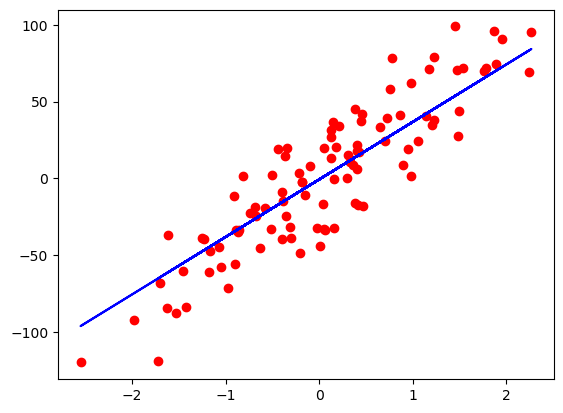

In [242]:
# 0. Preprocessing Data

X_numpy, Y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=0)

X = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(Y_numpy.astype(np.float32))
y = y.view(y.shape[0],1)

n_samples, n_features = X.shape

# 1. Model 
input_size = n_features
output = 1
model = nn.Linear(
    input_size,
    output_size
)

# 2. Loss and Optimizer
learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# 3. Training Loop
n_iters = 100
for epoch in range(n_iters):

    # Forward Pass
    y_pred = model(X)
    
    # Losss
    loss = criterion(y_pred, y)

    # Backward Pass
    loss.backward()
    
    # Update parameters
    optimizer.step()

    optimizer.zero_grad()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss: {loss.item():.4f}")

# 4. Plot
predicted = model(X).detach().numpy()
plt.plot(X_numpy, Y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()

# Breat Cancer

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# 0. Preprocessing Data
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

n_samples, n_features = X.shape
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# scale
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))
y_train = y_train.view(y_train.shape[0],1)
y_test = y_test.view(y_test.shape[0],1)


# 1. Model 
class LogisticRegression(nn.Module):
    def __init__(self, n_input_features):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(n_input_features, 1)
    
    def forward(self, x):
        y_predicted = torch.sigmoid(self.linear(x))
        return y_predicted 

model = LogisticRegression(n_features)

# 2. Loss and Optimizer
learning_rate = 0.01
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# 3. Training Loop
n_iters = 100
for epoch in range(n_iters):

    # Forward Pass
    y_pred = model(X_train)
    
    # Losss
    loss = criterion(y_pred, y_train)

    # Backward Pass
    loss.backward()
    
    # Update parameters
    optimizer.step()

    optimizer.zero_grad()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss: {loss.item():.4f}")

# 4. Evaluation
with torch.no_grad():
    y_predicted = model(X_test)
    y_predicted_classes = y_predicted.round()
    acc = y_predicted_classes.eq(y_test).sum() / float(y_test.shape[0])
    print(f"Accuracy: {acc:.4f}")

Epoch 0, loss: 0.9776
Epoch 10, loss: 0.6926
Epoch 20, loss: 0.5314
Epoch 30, loss: 0.4389
Epoch 40, loss: 0.3809
Epoch 50, loss: 0.3414
Epoch 60, loss: 0.3125
Epoch 70, loss: 0.2905
Epoch 80, loss: 0.2729
Epoch 90, loss: 0.2586
Accuracy: 0.9474


# Embbedings

In [3]:
import torch
import torch.nn as nn

emb = nn.Embedding(num_embeddings=5, embedding_dim=3)


In [4]:
emb = nn.Embedding(num_embeddings=5, embedding_dim=3)
emb

Embedding(5, 3)

In [5]:
emb.weight.data

tensor([[-0.5337, -0.2737, -0.1016],
        [-0.1511,  1.9615, -0.6651],
        [-0.1975,  0.0441,  0.4027],
        [-0.2127,  3.0811,  0.4332],
        [-0.2855, -0.5872,  0.0367]])

In [7]:
emb.weight

Parameter containing:
tensor([[-0.5337, -0.2737, -0.1016],
        [-0.1511,  1.9615, -0.6651],
        [-0.1975,  0.0441,  0.4027],
        [-0.2127,  3.0811,  0.4332],
        [-0.2855, -0.5872,  0.0367]], requires_grad=True)

In [6]:
x = torch.tensor([0, 2, 4])
y = emb(x)

print(y)


tensor([[ 1.0217,  1.2385, -0.5616],
        [ 0.5751,  1.7742,  0.4234],
        [ 0.5818, -0.0877,  0.2617]], grad_fn=<EmbeddingBackward0>)


In [8]:
vocab = {
    "I": 0,
    "love": 1,
    "NLP": 2
}

emb = nn.Embedding(3, 5)

sentence = torch.tensor([0, 1, 2])  # "I love NLP"
vectors = emb(sentence)

print(vectors.shape)


torch.Size([3, 5])


In [9]:
vectors

tensor([[ 0.5719, -2.5509,  0.0069, -1.0570, -0.1456],
        [-0.4711,  0.8104, -0.9476, -2.1275, -2.2296],
        [-2.4877,  1.1872, -2.4935, -0.2237, -1.5192]],
       grad_fn=<EmbeddingBackward0>)

In [10]:
emb.weight.data

tensor([[-0.0844, -0.2299,  1.4481, -0.4627, -0.7084],
        [ 0.7594,  0.2316, -0.0420,  1.2894,  0.4099],
        [ 0.9509,  0.3557, -0.4507, -1.0780,  0.3765]])

In [12]:
linear = nn.Linear(5, 1)

optimizer = torch.optim.SGD(list(emb.parameters()) + list(linear.parameters()), lr=0.1)

label = torch.tensor([1.0])

for _ in range(100):
    optimizer.zero_grad()
    x = emb(sentence).mean(dim=0)  # average word vectors
    y = linear(x)
    loss = (y - label).pow(2).mean()
    loss.backward()
    optimizer.step()

print(f"Final loss: {loss.item():.4f}")



Final loss: 0.0000


# SP 24 CS224N PyTorch Tutorial.ipynb

In [75]:
# Our raw data, which consists of sentences
corpus = [
          "We always come to Paris",
          "The professor is from Australia",
          "I live in Stanford",
          "She comes from Taiwan",
          "The capital of Turkey is Ankara"
         ]

In [76]:
def preprocess_sentence(sentence):
  return sentence.lower().split()

# Create our training set
train_sentences = [preprocess_sentence(sent) for sent in corpus]
train_sentences

[['we', 'always', 'come', 'to', 'paris'],
 ['the', 'professor', 'is', 'from', 'australia'],
 ['i', 'live', 'in', 'stanford'],
 ['she', 'comes', 'from', 'taiwan'],
 ['the', 'capital', 'of', 'turkey', 'is', 'ankara']]

In [77]:
# Set of locations that appear in our corpus
locations = set(["australia", "ankara", "paris", "stanford", "taiwan", "turkey"])

# Our train labels
train_labels = [[1 if word in locations else 0 for word in sent] for sent in train_sentences]
train_labels

[[0, 0, 0, 0, 1],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 1],
 [0, 0, 0, 1],
 [0, 0, 0, 1, 0, 1]]

In [ ]:
# Find all the unique words in our corpus
vocabulary = set(w for s in train_sentences for w in s)
# Add the unknown token to our vocabulary
vocabulary.add("<unk>")

# Add the <pad> token to our vocabulary to paste it at the end of shorter sentences
vocabulary.add("<pad>")

vocabulary

{'<pad>',
 '<unk>',
 'always',
 'ankara',
 'australia',
 'capital',
 'come',
 'comes',
 'from',
 'i',
 'in',
 'is',
 'live',
 'of',
 'paris',
 'professor',
 'she',
 'stanford',
 'taiwan',
 'the',
 'to',
 'turkey',
 'we'}

In [82]:
# Function that pads the given sentence
# We are introducing this function here as an example
# We will be utilizing it later in the tutorial
def pad_window(sentence, window_size, pad_token="<pad>"):
  window = [pad_token] * window_size
  return window + sentence + window

# Show padding example
window_size = 2
pad_window(train_sentences[0], window_size=window_size)

['<pad>', '<pad>', 'we', 'always', 'come', 'to', 'paris', '<pad>', '<pad>']

In [83]:
# We are just converting our vocabularly to a list to be able to index into it
# Sorting is not necessary, we sort to show an ordered word_to_ind dictionary
# That being said, we will see that having the index for the padding token
# be 0 is convenient as some PyTorch functions use it as a default value
# such as nn.utils.rnn.pad_sequence, which we will cover in a bit
ix_to_word = sorted(list(vocabulary))

# Creating a dictionary to find the index of a given word
word_to_ix = {word: ind for ind, word in enumerate(ix_to_word)}
word_to_ix

{'<pad>': 0,
 '<unk>': 1,
 'always': 2,
 'ankara': 3,
 'australia': 4,
 'capital': 5,
 'come': 6,
 'comes': 7,
 'from': 8,
 'i': 9,
 'in': 10,
 'is': 11,
 'live': 12,
 'of': 13,
 'paris': 14,
 'professor': 15,
 'she': 16,
 'stanford': 17,
 'taiwan': 18,
 'the': 19,
 'to': 20,
 'turkey': 21,
 'we': 22}

In [84]:
# Given a sentence of tokens, return the corresponding indices
def convert_token_to_indices(sentence, word_to_ix):
  indices = []
  for token in sentence:
    # Check if the token is in our vocabularly. If it is, get it's index.
    # If not, get the index for the unknown token.
    if token in word_to_ix:
      index = word_to_ix[token]
    else:
      index = word_to_ix["<unk>"]
    indices.append(index)
  return indices

# More compact version of the same function
def _convert_token_to_indices(sentence, word_to_ix):
  return [word_to_ind.get(token, word_to_ix["<unk>"]) for token in sentence]

# Show an example
example_sentence = ["we", "always", "come", "to", "kuwait"]
example_indices = convert_token_to_indices(example_sentence, word_to_ix)
restored_example = [ix_to_word[ind] for ind in example_indices]

print(f"Original sentence is: {example_sentence}")
print(f"Going from words to indices: {example_indices}")
print(f"Going from indices to words: {restored_example}")

Original sentence is: ['we', 'always', 'come', 'to', 'kuwait']
Going from words to indices: [22, 2, 6, 20, 1]
Going from indices to words: ['we', 'always', 'come', 'to', '<unk>']


In [85]:
# Converting our sentences to indices
example_padded_indices = [convert_token_to_indices(s, word_to_ix) for s in train_sentences]
example_padded_indices

[[22, 2, 6, 20, 14],
 [19, 15, 11, 8, 4],
 [9, 12, 10, 17],
 [16, 7, 8, 18],
 [19, 5, 13, 21, 11, 3]]

In [87]:
# Creating an embedding table for our words
embedding_dim = 5
embeds = torch.nn.Embedding(len(vocabulary), embedding_dim)

# Printing the parameters in our embedding table
list(embeds.parameters())

[Parameter containing:
 tensor([[-0.2598, -0.3545, -0.3698, -1.6801, -1.4513],
         [-0.4706, -2.1174,  1.5156,  0.7256,  0.3417],
         [ 0.0396,  1.5225,  1.1678,  0.2206,  0.2823],
         [ 0.7817,  0.1623, -1.8224, -1.1570, -0.3792],
         [-0.0378, -0.8866, -1.2924,  1.1702, -0.8266],
         [-1.2515, -0.0489, -0.7744,  0.4143, -0.8673],
         [-0.3357, -1.5229, -0.8181,  2.5698, -0.1195],
         [ 1.1884,  0.2871, -0.0454,  0.1454,  0.9570],
         [ 1.6998,  0.3462, -2.5672, -1.2738,  0.5928],
         [ 2.7128,  1.3174,  1.6340,  1.3095, -0.0840],
         [-0.0214, -0.1454, -1.3793,  0.7874,  0.2202],
         [-0.8673, -0.6271, -1.6070,  0.0787,  0.2076],
         [ 0.2177,  0.5331, -0.6201,  0.3340, -0.9062],
         [-0.0604, -0.8636, -0.2808,  0.4719, -0.6750],
         [ 0.4066,  1.2101, -1.6051, -0.6923,  0.2167],
         [-0.8086,  1.6589,  0.7867,  0.2198,  0.2589],
         [-0.1811, -0.0149,  0.6220,  0.0824,  2.7689],
         [ 0.1911,  0.126

In [88]:
# Get the embedding for the word Paris
index = word_to_ix["paris"]
index_tensor = torch.tensor(index, dtype=torch.long)
paris_embed = embeds(index_tensor)
paris_embed

tensor([ 0.4066,  1.2101, -1.6051, -0.6923,  0.2167],
       grad_fn=<EmbeddingBackward0>)

In [89]:
# We can also get multiple embeddings at once
index_paris = word_to_ix["paris"]
index_ankara = word_to_ix["ankara"]
indices = [index_paris, index_ankara]
indices_tensor = torch.tensor(indices, dtype=torch.long)
embeddings = embeds(indices_tensor)
embeddings

tensor([[ 0.4066,  1.2101, -1.6051, -0.6923,  0.2167],
        [ 0.7817,  0.1623, -1.8224, -1.1570, -0.3792]],
       grad_fn=<EmbeddingBackward0>)

In [98]:
from torch.utils.data import DataLoader
from functools import partial

def custom_collate_fn(batch, window_size, word_to_ix):
  # Break our batch into the training examples (x) and labels (y)
  # We are turning our x and y into tensors because nn.utils.rnn.pad_sequence
  # method expects tensors. This is also useful since our model will be
  # expecting tensor inputs.
  x, y = zip(*batch)

  # Now we need to window pad our training examples. We have already defined a
  # function to handle window padding. We are including it here again so that
  # everything is in one place.
  def pad_window(sentence, window_size, pad_token="<pad>"):
    window = [pad_token] * window_size
    return window + sentence + window

  # Pad the train examples.
  x = [pad_window(s, window_size=window_size) for s in x]

  # Now we need to turn words in our training examples to indices. We are
  # copying the function defined earlier for the same reason as above.

  def convert_tokens_to_indices(sentence, word_to_ix):
      return [word_to_ix.get(token, word_to_ix["<unk>"]) for token in sentence]

  # Convert the train examples into indices.
  x = [convert_tokens_to_indices(s, word_to_ix) for s in x]

  # We will now pad the examples so that the lengths of all the example in
  # one batch are the same, making it possible to do matrix operations.
  # We set the batch_first parameter to True so that the returned matrix has
  # the batch as the first dimension.
  pad_token_ix = word_to_ix["<pad>"]

  # pad_sequence function expects the input to be a tensor, so we turn x into one
  x = [torch.LongTensor(x_i) for x_i in x]
  x_padded = nn.utils.rnn.pad_sequence(x, batch_first=True, padding_value=pad_token_ix)

  # We will also pad the labels. Before doing so, we will record the number
  # of labels so that we know how many words existed in each example.
  lengths = [len(label) for label in y]
  lenghts = torch.LongTensor(lengths)

  y = [torch.LongTensor(y_i) for y_i in y]
  y_padded = torch.nn.utils.rnn.pad_sequence(y, batch_first=True, padding_value=0)

  # We are now ready to return our variables. The order we return our variables
  # here will match the order we read them in our training loop.
  return x_padded, y_padded, lenghts

In [102]:
def _custom_collate_fn(batch, window_size, word_to_ix):
  # Prepare the datapoints
  x, y = zip(*batch)
  x = [pad_window(s, window_size=window_size) for s in x]
  x = [convert_tokens_to_indices(s, word_to_ix) for s in x]

  # Pad x so that all the examples in the batch have the same size
  pad_token_ix = word_to_ix["<pad>"]
  x = [torch.LongTensor(x_i) for x_i in x]
  x_padded = nn.utils.rnn.pad_sequence(x, batch_first=True, padding_value=pad_token_ix)

  # Pad y and record the length
  lengths = [len(label) for label in y]
  lenghts = torch.LongTensor(lengths)
  y = [torch.LongTensor(y_i) for y_i in y]
  y_padded = nn.utils.rnn.pad_sequence(y, batch_first=True, padding_value=0)

  return x_padded, y_padded, lenghts

In [103]:
# Parameters to be passed to the DataLoader
data = list(zip(train_sentences, train_labels))
batch_size = 2
shuffle = True
window_size = 2
collate_fn = partial(custom_collate_fn, window_size=window_size, word_to_ix=word_to_ix)

# Instantiate the DataLoader
loader = DataLoader(data, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

# Go through one loop
counter = 0
for batched_x, batched_y, batched_lengths in loader:
  print(f"Iteration {counter}")
  print("Batched Input:")
  print(batched_x)
  print("Batched Labels:")
  print(batched_y)
  print("Batched Lengths:")
  print(batched_lengths)
  print("")
  counter += 1

Iteration 0
Batched Input:
tensor([[ 0,  0,  9, 12, 10, 17,  0,  0,  0],
        [ 0,  0, 19, 15, 11,  8,  4,  0,  0]])
Batched Labels:
tensor([[0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]])
Batched Lengths:
tensor([4, 5])

Iteration 1
Batched Input:
tensor([[ 0,  0, 16,  7,  8, 18,  0,  0,  0],
        [ 0,  0, 22,  2,  6, 20, 14,  0,  0]])
Batched Labels:
tensor([[0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]])
Batched Lengths:
tensor([4, 5])

Iteration 2
Batched Input:
tensor([[ 0,  0, 19,  5, 13, 21, 11,  3,  0,  0]])
Batched Labels:
tensor([[0, 0, 0, 1, 0, 1]])
Batched Lengths:
tensor([6])



In [104]:
# Print the original tensor
print(f"Original Tensor: ")
print(batched_x)
print("")

# Create the 2 * 2 + 1 chunks
chunk = batched_x.unfold(1, window_size*2 + 1, 1)
print(f"Windows: ")
print(chunk)

Original Tensor: 
tensor([[ 0,  0, 19,  5, 13, 21, 11,  3,  0,  0]])

Windows: 
tensor([[[ 0,  0, 19,  5, 13],
         [ 0, 19,  5, 13, 21],
         [19,  5, 13, 21, 11],
         [ 5, 13, 21, 11,  3],
         [13, 21, 11,  3,  0],
         [21, 11,  3,  0,  0]]])
